In [1]:
import sys
print(sys.executable)

e:\my-learning\my-enhanced-projects-krish\Solar_Panel_Classification\solar-classification\Scripts\python.exe


In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt
from pathlib import Path


In [3]:
notebook_dir = Path.cwd()
DATASET_DIR = notebook_dir / "Data"

# data_dir = "/content/Data"

# print(os.listdir(data_dir))

if DATASET_DIR.exists():
    print("✅ Data directory found!")
else:
    print("❌ Data directory not found. Please check the folder structure.")

✅ Data directory found!


In [4]:
DATASET_DIR
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32
SEED = 42

In [5]:
	 train_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split = 0.2,
    subset="training",
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size = BATCH_SIZE,
    seed = SEED
)

Found 885 files belonging to 6 classes.
Using 708 files for training.


In [6]:
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split = 0.2,
    subset="validation",
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size = BATCH_SIZE,
    seed = SEED
)

Found 885 files belonging to 6 classes.
Using 177 files for validation.


In [7]:
class_names = train_dataset.class_names
num_classes = len(class_names)

In [8]:
class_names

['Bird-drop',
 'Clean',
 'Dusty',
 'Electrical-damage',
 'Physical-Damage',
 'Snow-Covered']

In [9]:
num_classes

6

### Base Model (CNN2D)

In [10]:
model = tf.keras.models.Sequential()
model.add(tf.keras.layers.Rescaling(1.0/255, input_shape=(IMG_HEIGHT,IMG_WIDTH, 3)))

# Layer 1
model.add(tf.keras.layers.Conv2D(32,(3,3), activation='relu'))
model.add(tf.keras.layers.MaxPooling2D((2,2)))

# Convolution layer: 2
model.add(tf.keras.layers.Conv2D(64, (3,3), activation="relu"))
model.add(tf.keras.layers.MaxPooling2D((2,2)))

# Convolution layer: 3
model.add(tf.keras.layers.Conv2D(128, (3,3), activation="relu"))
model.add(tf.keras.layers.MaxPooling2D((2,2)))

model.add(tf.keras.layers.Flatten())

model.add(tf.keras.layers.Dense(128, activation="relu"))

model.add(tf.keras.layers.Dense(num_classes, activation='softmax'))



e:\my-learning\my-enhanced-projects-krish\Solar_Panel_Classification\solar-classification\lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [11]:
model.compile(optimizer='adam', loss= "sparse_categorical_crossentropy", metrics = ['accuracy'])

In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,734 (42.61 MB)

 Trainable params: 11,169,734 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
EPOCHS=20

In [14]:
history = model.fit(
    train_dataset,
    validation_data = validation_dataset,
    epochs = EPOCHS
)

Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 38s 1s/step - accuracy: 0.2585 - loss: 2.2112 - val_accuracy: 0.3842 - val_loss: 1.5771
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.3799 - loss: 1.5377 - val_accuracy: 0.3785 - val_loss: 1.5330
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.4845 - loss: 1.3428 - val_accuracy: 0.4746 - val_loss: 1.3891
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.5918 - loss: 1.1249 - val_accuracy: 0.5650 - val_loss: 1.1725
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 38s 1s/step - accuracy: 0.7062 - loss: 0.8476 - val_accuracy: 0.5593 - val_loss: 1.5097
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - accuracy: 0.7472 - loss: 0.8260 - val_accuracy: 0.5085 - val_loss: 1.6157
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/step - accuracy: 0.8136 - loss: 0.5352 - val_accuracy: 0.5819 - val_loss: 1.3548
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/step - accuracy: 0.8559 - loss: 0.3622 - val_accuracy: 0.4859 - val_loss:

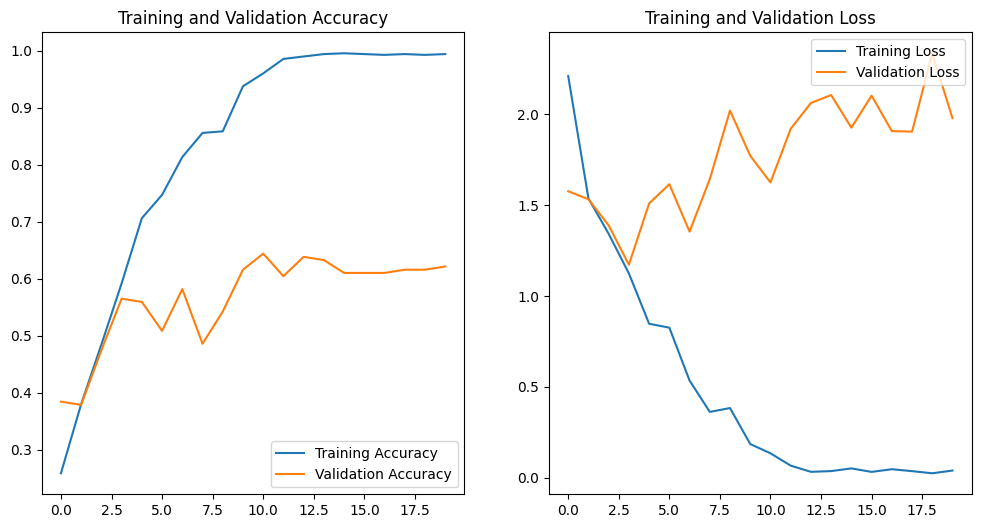

In [15]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(EPOCHS)


plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')


plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

#### Solve the Overfitting problem

In [16]:
from tensorflow.keras.callbacks import EarlyStopping

In [17]:
data_augmentation = tf.keras.Sequential([
  tf.keras.layers.RandomFlip("horizontal_and_vertical"),
  tf.keras.layers.RandomRotation(0.2),
  tf.keras.layers.RandomZoom(0.2),
])

# Example of adding dropout before your Dense layers
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dropout(0.5)) # Drops out 50% of connections
model.add(tf.keras.layers.Dense(128, activation="relu"))
model.add(tf.keras.layers.Dense(num_classes, activation='softmax'))


In [18]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3, # Stop after 3 epochs of no improvement
    restore_best_weights=True # Keep the best model
)

history1 = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS,
    callbacks=[early_stopping]
)


Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.9944 - loss: 0.0324 - val_accuracy: 0.6271 - val_loss: 1.8834
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - accuracy: 0.9958 - loss: 0.0285 - val_accuracy: 0.6441 - val_loss: 1.9888
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/step - accuracy: 0.9901 - loss: 0.0433 - val_accuracy: 0.6497 - val_loss: 2.0822
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/step - accuracy: 0.9944 - loss: 0.0171 - val_accuracy: 0.6384 - val_loss: 1.9200
